# Phase 3

# CELL 1  -  Imports

In [1]:
import sys, io

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from itertools import combinations

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint, CSVLogger)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("[OK] TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"[OK] GPUs available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s).")
else:
    print("[WARN] No GPU! Enable GPU: Kaggle Settings -> Accelerator -> GPU P100.")


2026-07-02 02:24:27.341826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782959067.649846      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782959067.717568      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782959068.899315      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782959068.899363      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782959068.899366      58 computation_placer.cc:177] computation placer alr

[OK] TensorFlow version: 2.19.0
[OK] GPUs available: 1
[OK] GPU memory growth enabled for 1 GPU(s).


# CELL 2  -  Configuration

## To find path of Phase 1+2 notebook output

In [2]:
# Run this to find the exact path inside /kaggle/input/notebooks/
import os
from pathlib import Path

print("=== Searching for phase1_outputs ===\n")

# Search 3 levels deep under /kaggle/input/
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth > 3:
        continue  # don't go too deep
    indent = "  " * depth
    print(f"{indent}{root}/")
    if "phase1_outputs" in dirs:
        full_path = Path(root) / "phase1_outputs"
        print(f"\n{'='*50}")
        print(f"  FOUND: {full_path}")
        print(f"  Use this in Cell 2:")
        print(f"  PHASE12_INPUT = Path(\"{full_path}\")")
        print(f"{'='*50}\n")

=== Searching for phase1_outputs ===

/kaggle/input/
  /kaggle/input/notebooks/
    /kaggle/input/notebooks/bobbi12235/
      /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/

  FOUND: /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Use this in Cell 2:
  PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")

  /kaggle/input/datasets/
    /kaggle/input/datasets/kmader/
      /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/


In [3]:
# CELL 2 — Configuration for Phase 3 standalone notebook
import os, json
from pathlib import Path

# ── HAM10000 real images ──────────────────────────────────────────────────
HAM10000_INPUT = Path("/kaggle/input/skin-cancer-mnist-ham10000")

# ── Phase 1+2 preprocessed outputs ───────────────────────────────────────
# Kaggle mounts added datasets at /kaggle/input/[dataset-slug]/
PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")

# Verify the Phase12 dataset is mounted
if not PHASE12_INPUT.exists():
    raise FileNotFoundError(
        f"Phase 1+2 dataset not found at {PHASE12_INPUT}\n"
        "Add 'melanoscan-phase12-outputs' as an input dataset to this notebook:\n"
        "  Notebook Settings (right panel) → Add Data → Your Datasets → melanoscan-phase12-outputs"
    )

# ── Output paths for this notebook ───────────────────────────────────────
OUTPUT_DIR  = Path("/kaggle/working/phase3_outputs")
MODELS_DIR  = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"
SPLITS_DIR  = PHASE12_INPUT / "splits"    # read from Phase12 dataset

for d in [OUTPUT_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Model config ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
N_CLASSES   = 7
BATCH_SIZE  = 32
EPOCHS      = 40
LR_INIT     = 1e-3
LR_FINETUNE = 1e-5
SEED        = 42

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_LABELS = {
    "akiec": "Actinic Keratoses", "bcc": "Basal Cell Carcinoma",
    "bkl"  : "Benign Keratosis",  "df" : "Dermatofibroma",
    "mel"  : "Melanoma",          "nv" : "Melanocytic Nevi",
    "vasc" : "Vascular Lesions"
}
dx_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print("[OK] Configuration complete.")
print(f"  Phase12 dataset : {PHASE12_INPUT}")
print(f"  Model outputs   : {MODELS_DIR}")
print(f"  Classes         : {CLASS_NAMES}")

[OK] Configuration complete.
  Phase12 dataset : /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Model outputs   : /kaggle/working/phase3_outputs/models
  Classes         : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# CELL 3  -  Load Splits

In [4]:
# CELL 3 — Load Splits with automatic path remapping + Model A standard baseline split
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# ── Path remapping helper ─────────────────────────────────────────────────────
def remap_image_paths(df, phase12_input_path):
    """
    The augmented CSV was built in Notebook 1 where synthetic images lived at:
      /kaggle/working/phase1_outputs/synthetic_images/...
    In this notebook they are mounted at:
      /kaggle/input/melanoscan-phase12-outputs/phase1_outputs/synthetic_images/...
    This function remaps all synthetic paths. Real HAM10000 paths are unchanged.
    """
    OLD_BASE = "/kaggle/working/phase1_outputs"
    NEW_BASE = str(phase12_input_path)
    if "image_path" in df.columns:
        n_before = df["image_path"].str.startswith(OLD_BASE).sum()
        df["image_path"] = df["image_path"].str.replace(
            OLD_BASE, NEW_BASE, regex=False
        )
        if n_before > 0:
            print(f"  Remapped {n_before:,} synthetic image paths")
    return df


# ── Load intersectional stratified splits (used by Models B, C, D, E) ────────
df_train_baseline = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_train_v1       = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_val            = pd.read_csv(SPLITS_DIR / "val_split.csv")
df_test           = pd.read_csv(SPLITS_DIR / "test_split.csv")

# Load augmented CSV with cGAN synthetic images (used by Models D and E)
aug_path = SPLITS_DIR / "train_split_augmented_v2.csv"
if aug_path.exists():
    df_train_v2 = pd.read_csv(aug_path)
    print("Remapping synthetic image paths in augmented dataset...")
    df_train_v2 = remap_image_paths(df_train_v2, PHASE12_INPUT)
    print(f"  [OK] Augmented dataset: {len(df_train_v2):,} samples")
else:
    print("[WARN] Augmented CSV not found — Models D and E will use original training data.")
    df_train_v2 = pd.read_csv(SPLITS_DIR / "train_split.csv")


# ── Model A: Standard 80/20 split — replicates Ali et al. (2022) ─────────────
# Ali et al. trained EfficientNetB0-B7 on HAM10000 using a standard random
# class-stratified split WITHOUT intersectional demographic stratification.
# This is the published-methodology baseline that shows demographic bias
# before any of the three preprocessing components are applied.
#
# IMPORTANT: All 5 models are EVALUATED on the same df_test for fair comparison.
# Only the TRAINING data differs for Model A.
df_full = pd.concat([
    pd.read_csv(SPLITS_DIR / "train_split.csv"),
    pd.read_csv(SPLITS_DIR / "val_split.csv"),
    pd.read_csv(SPLITS_DIR / "test_split.csv"),
], ignore_index=True)

df_modelA_train, _ = train_test_split(
    df_full,
    test_size=0.20,
    stratify=df_full["dx"],   # stratified on class label only — NO demographic axes
    random_state=42
)
df_modelA_train = df_modelA_train.reset_index(drop=True)


# ── Encode labels (dx string → integer index) for all splits ─────────────────
for df in [df_modelA_train, df_train_baseline,
           df_train_v1, df_train_v2, df_val, df_test]:
    df["label"] = df["dx"].map(dx_to_idx)


# ── Sanity check: verify a sample of augmented image paths exist ──────────────
sample_paths = random.sample(df_train_v2["image_path"].tolist(),
                             min(5, len(df_train_v2)))
missing = [p for p in sample_paths if not Path(p).exists()]
if missing:
    print(f"\n[WARN] {len(missing)} sampled image paths do not exist.")
    for p in missing:
        print(f"  MISSING: {p}")
else:
    print("\n  [OK] Sampled augmented image paths verified — all exist.")


# ── Summary ───────────────────────────────────────────────────────────────────
print(f"""
{'='*60}
  DATASET SUMMARY — 5-MODEL ABLATION STUDY
{'='*60}
  Model A  (Standard Baseline — Ali et al. 2022 replication)
           Train : {len(df_modelA_train):,}  |  nv%: {(df_modelA_train['dx']=='nv').mean()*100:.1f}%
           Split : Standard 80/20, class-stratified only
           Method: No sampling / No weights / No cGAN

  Model B  (Component 1: Intersectional Stratified Sampling)
           Train : {len(df_train_v1):,}  |  nv%: {(df_train_v1['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 (4-axis stratification)
           Method: Sampling only / No weights / No cGAN

  Model C  (Component 2: Adaptive Distribution-Aware Reweighting)
           Train : {len(df_train_baseline):,}  |  nv%: {(df_train_baseline['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15
           Method: Sampling + Class weights / No cGAN

  Model D  (Component 3: Quality-Controlled cGAN Augmentation)
           Train : {len(df_train_v2):,}  |  nv%: {(df_train_v2['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 + cGAN synthetic images
           Method: Sampling + cGAN / No weights

  Model E  (Full Framework — deployed in MelanoScan HMS)
           Train : {len(df_train_v2):,}  |  nv%: {(df_train_v2['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 + cGAN synthetic images
           Method: Sampling + Weights + cGAN (ALL three components)

  Validation : {len(df_val):,}  (shared across all models)
  Test       : {len(df_test):,}  (shared across all models)

  NOTE: All 5 models evaluated on the SAME df_test for fair comparison.
{'='*60}
""")

Remapping synthetic image paths in augmented dataset...
  Remapped 3,660 synthetic image paths
  [OK] Augmented dataset: 10,670 samples

  [OK] Sampled augmented image paths verified — all exist.

  DATASET SUMMARY — 5-MODEL ABLATION STUDY
  Model A  (Standard Baseline — Ali et al. 2022 replication)
           Train : 7,966  |  nv%: 66.9%
           Split : Standard 80/20, class-stratified only
           Method: No sampling / No weights / No cGAN

  Model B  (Component 1: Intersectional Stratified Sampling)
           Train : 7,010  |  nv%: 66.6%
           Split : Intersectional 70/15/15 (4-axis stratification)
           Method: Sampling only / No weights / No cGAN

  Model C  (Component 2: Adaptive Distribution-Aware Reweighting)
           Train : 7,010  |  nv%: 66.6%
           Split : Intersectional 70/15/15
           Method: Sampling + Class weights / No cGAN

  Model D  (Component 3: Quality-Controlled cGAN Augmentation)
           Train : 10,670  |  nv%: 48.2%
           Spl

# CELL 4  -  tf.data Pipeline

In [5]:
# CELL 4  —  tf.data Pipeline  (FIXED v2: sample-weight + demographic-weight support)
from sklearn.utils.class_weight import compute_class_weight

AUTOTUNE = tf.data.AUTOTUNE

# ── Image loaders ──────────────────────────────────────────────────────────────
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)          # ← [0, 255] — NO /255.0
    return img, label

def load_image_with_weight(image_path, label, weight):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)          # ← [0, 255] — NO /255.0
    return img, label, weight

# ── Augmentation ────────────────────────────────────────────────────────────────
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 255.0) # ← clip to [0, 255]
    return img, label

def augment_image_with_weight(img, label, weight):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 255.0) # ← clip to [0, 255]
    return img, label, weight

# ── Dataset builders ────────────────────────────────────────────────────────────
def build_dataset(df, shuffle=False, augment_flag=False, batch_size=BATCH_SIZE):
    paths  = df["image_path"].tolist()
    labels = df["label"].tolist()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        dataset = dataset.map(augment_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(df), 4096), seed=SEED)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

def build_dataset_weighted(df, weight_col="combined_weight", shuffle=False,
                            augment_flag=False, batch_size=BATCH_SIZE):
    paths   = df["image_path"].tolist()
    labels  = df["label"].tolist()
    weights = df[weight_col].astype("float32").tolist()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels, weights))
    dataset = dataset.map(load_image_with_weight, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        dataset = dataset.map(augment_image_with_weight, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(df), 4096), seed=SEED)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

# ── Weight helpers ───────────────────────────────────────────────────────────────
def get_class_weights(df):
    labels  = df["label"].values
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw = dict(zip(classes.tolist(), weights.tolist()))
    print(f"  Balanced class weights: { {CLASS_NAMES[k]: round(v, 3) for k, v in cw.items()} }")
    return cw

def get_combined_weights(df, class_weight_dict, mel_boost=2.0):
    """
    FIX: Apply the Phase-1 demographic sample_weights that were computed in
    Step 1.3 (adaptive distribution-aware reweighting) but NEVER actually used
    in model training in the original notebook.

    Formula per sample i:
        w_i = sample_weight_i  x  class_weight[label_i]  x  mel_boost_i
    where mel_boost_i = mel_boost if label == mel else 1.0.
    Normalised so mean(w) = 1.0 to preserve effective sample size.

    sample_weight  : intersectional demographic weight from train_split.csv
                     (rare age/sex/location groups get higher weights)
    class_weight   : balanced class weight from sklearn (counters nv 67% dominance)
    mel_boost      : extra multiplier on melanoma — missed melanoma (FN) is
                     clinically far more dangerous than false alarms (FP)
    """
    df = df.copy()
    MEL_IDX = CLASS_NAMES.index("mel")
    NV_IDX  = CLASS_NAMES.index("nv")

    if "sample_weight" not in df.columns:
        print("  [WARN] No sample_weight column — using class weights only.")
        df["sample_weight"] = 1.0

    def _w(row):
        cw    = class_weight_dict.get(int(row["label"]), 1.0)
        sw    = float(row["sample_weight"])
        boost = mel_boost if int(row["label"]) == MEL_IDX else 1.0
        return sw * cw * boost

    df["combined_weight"] = df.apply(_w, axis=1)
    mean_w = df["combined_weight"].mean()
    df["combined_weight"] = df["combined_weight"] / mean_w

    w     = df["combined_weight"]
    mel_w = df.loc[df["label"] == MEL_IDX, "combined_weight"].mean()
    nv_w  = df.loc[df["label"] == NV_IDX,  "combined_weight"].mean()
    print(f"  Combined weights — mean={w.mean():.3f}  max={w.max():.2f}  min={w.min():.4f}")
    print(f"  mel avg weight={mel_w:.3f}   nv avg weight={nv_w:.3f}   mel/nv ratio={mel_w/nv_w:.1f}x")
    return df

# ── Build evaluation datasets ───────────────────────────────────────────────────
val_ds  = build_dataset(df_val,  shuffle=False, augment_flag=False)
test_ds = build_dataset(df_test, shuffle=False, augment_flag=False)

print("[OK] Datasets built. Images in [0,255] for EfficientNetB0.")
print(f"  Val : {len(df_val):,} samples | Test: {len(df_test):,} samples")

[OK] Datasets built. Images in [0,255] for EfficientNetB0.
  Val : 1,474 samples | Test: 1,474 samples


I0000 00:00:1782959115.158136      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# CELL 5  -  Model Architecture (EfficientNet-B0 + Custom Head)

In [6]:
# CELL 5  —  Model Architecture + Callbacks  (FIXED v2)
def build_model(n_classes=N_CLASSES, dropout_rate=0.4):
    inputs = keras.Input(shape=IMG_SHAPE)

    # Feed directly into EfficientNetB0 — NO Rescaling layer
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_tensor=inputs, pooling=None)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_INIT),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base


def get_callbacks(model_name, monitor="val_loss"):
    """
    FIX: Monitor val_loss instead of val_accuracy.

    ROOT CAUSE of original class-collapse in Models A & C:
      EarlyStopping watched val_accuracy (patience=8, restore_best_weights=True).
      A model that only predicts nv achieves ~0.67 val_accuracy immediately.
      When class/sample weights push the model to learn minority classes,
      val_accuracy temporarily DROPS below 0.67 (the model now sometimes predicts
      mel/akiec/etc. instead of nv, lowering overall accuracy on the nv-heavy val
      set). EarlyStopping interprets this drop as regression, fires after 8 epochs,
      and restore_best_weights returns the nv-only checkpoint from epoch ~1.
      Model C was most affected because 3,660 noisy synthetic images slow early
      learning, giving EarlyStopping time to fire before any minority-class
      improvement appears.

    Fix: val_loss decreases steadily as the weighted cross-entropy improves for
    all 7 classes — EarlyStopping no longer fires on the transient accuracy dip.
    Patience increased to 10 (from 8) and ReduceLROnPlateau patience to 5.
    """
    mode = "min"
    return [
        EarlyStopping(monitor=monitor, patience=10, restore_best_weights=True,
                      verbose=1, mode=mode),
        ReduceLROnPlateau(monitor=monitor, factor=0.3, patience=5,
                          min_lr=1e-7, verbose=1, mode=mode),
        ModelCheckpoint(str(MODELS_DIR / f"{model_name}_best.h5"),
                        monitor=monitor, save_best_only=True, verbose=0, mode=mode),
        CSVLogger(str(RESULTS_DIR / f"{model_name}_training_log.csv")),
    ]

print("[OK] Model defined. EfficientNetB0 normalises [0,255] inputs internally.")
print("     EarlyStopping  : val_loss, patience=10, mode=min")
print("     ReduceLROnPlateau: val_loss, patience=5,  mode=min")

[OK] Model defined. EfficientNetB0 normalises [0,255] inputs internally.
     EarlyStopping  : val_loss, patience=10, mode=min
     ReduceLROnPlateau: val_loss, patience=5,  mode=min


# CELL 6  -  Helper: Two-Phase Training (Freeze -> Unfreeze)

In [7]:
# CELL 6  —  Two-Phase Training Helper  (FIXED v2)
def train_model(model_name, train_df,
                use_class_weight   = False,
                use_sample_weights = False,
                augment            = True,
                mel_boost          = 1.0):
    """
    Two-phase EfficientNet-B0 training.

    Parameters
    ----------
    use_class_weight   : bool  — pass sklearn balanced class weights via
                                  class_weight= dict to model.fit().
                                  Used only when use_sample_weights=False.
    use_sample_weights : bool  — embed combined (demographic x class x mel_boost)
                                  weights into the tf.data dataset as (img,lbl,w)
                                  3-tuples. TF applies them as sample_weight.
                                  This finally activates the Phase-1 demographic
                                  weights that were computed but unused before.
    mel_boost          : float — extra multiplier on melanoma class weight.
    """
    print(f"\n{'='*60}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*60}")
    print(f"  Samples          : {len(train_df):,}")
    print(f"  Class weighting  : {use_class_weight}")
    print(f"  Sample weighting : {use_sample_weights}  (demographic x class x mel_boost)")
    print(f"  Melanoma boost   : {mel_boost}x")
    print(f"  Augmentation     : {augment}")

    # ── Class distribution diagnostic ─────────────────────────────────────────
    print(f"\n  Class distribution:")
    counts = train_df["label"].value_counts().sort_index()
    for idx, cnt in counts.items():
        bar = "#" * int(cnt / len(train_df) * 40)
        print(f"    {CLASS_NAMES[int(idx)]:8s} {cnt:>6,} ({cnt/len(train_df)*100:4.1f}%)  {bar}")

    # ── Build dataset + prepare fit kwargs ────────────────────────────────────
    if use_sample_weights:
        print(f"\n  [FIX] Computing combined demographic x class weights (mel_boost={mel_boost})...")
        cw_dict    = get_class_weights(train_df)
        train_df_w = get_combined_weights(train_df, cw_dict, mel_boost=mel_boost)
        train_ds   = build_dataset_weighted(train_df_w, weight_col="combined_weight",
                                            shuffle=True, augment_flag=augment,
                                            batch_size=BATCH_SIZE)
        fit_kwargs = {}           # weights are embedded in the dataset 3-tuple

    elif use_class_weight:
        print(f"\n  Computing balanced class weights (dict mode)...")
        cw_dict    = get_class_weights(train_df)
        train_ds   = build_dataset(train_df, shuffle=True, augment_flag=augment,
                                   batch_size=BATCH_SIZE)
        fit_kwargs = {"class_weight": cw_dict}

    else:
        print(f"\n  [BASELINE] No weighting. Model expected to collapse to nv majority.")
        train_ds   = build_dataset(train_df, shuffle=True, augment_flag=augment,
                                   batch_size=BATCH_SIZE)
        fit_kwargs = {}

    model, base = build_model()

    # ── Phase 1: Head only (backbone frozen) ──────────────────────────────────
    print(f"\n  [Phase 1] Head-only  (backbone frozen, LR={LR_INIT}) ...")
    h1 = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        callbacks       = get_callbacks(f"{model_name}_phase1", monitor="val_loss"),
        verbose         = 1,
        **fit_kwargs
    )
    p1_best = min(h1.history["val_loss"])
    p1_acc  = max(h1.history["val_accuracy"])
    print(f"  Phase 1 best -> val_loss={p1_best:.4f}  val_acc={p1_acc:.4f}")

    # ── Phase 2: Fine-tune top 30 backbone layers ──────────────────────────────
    print(f"\n  [Phase 2] Fine-tune top 30 layers  (LR={LR_FINETUNE}) ...")
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=LR_FINETUNE),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    h2 = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        callbacks       = get_callbacks(f"{model_name}_phase2", monitor="val_loss"),
        verbose         = 1,
        **fit_kwargs
    )
    p2_best = min(h2.history["val_loss"])
    p2_acc  = max(h2.history["val_accuracy"])
    print(f"  Phase 2 best -> val_loss={p2_best:.4f}  val_acc={p2_acc:.4f}")

    model.save(str(MODELS_DIR / f"{model_name}_final.h5"))
    print(f"\n  [OK] {model_name}_final.h5 saved.")

    combined_history = {
        "accuracy"    : h1.history["accuracy"]    + h2.history["accuracy"],
        "val_accuracy": h1.history["val_accuracy"] + h2.history["val_accuracy"],
        "loss"        : h1.history["loss"]         + h2.history["loss"],
        "val_loss"    : h1.history["val_loss"]     + h2.history["val_loss"],
    }
    return model, combined_history

# CELL 7  -  STEP 1.5: Train All Three Models

In [8]:
# CELL 7  —  Train All Five Models (Ablation Study)
# Uses the parameter names defined in your Cell 6 train_model() function:
#   use_class_weight   = bool (sklearn balanced class_weight dict)
#   use_sample_weights = bool (combined demographic × class weights in dataset)
#   mel_boost          = float (extra weight on melanoma class)

# Initialise histories dict before training
histories = {}

# ── MODEL A: Standard baseline — replicates Ali et al. (2022) EfficientNetB0 ──
# No class weights, no intersectional sampling, no cGAN.
# Trained on standard 80/20 class-stratified split (df_modelA_train).
# Expected: highest overall accuracy, highest demographic bias (EOD).
print("\n" + "█"*60)
print("  MODEL A — Published Baseline (Standard EfficientNetB0)")
print("  Reference: Ali et al. (2022), DOI: 10.1016/j.neuri.2021.100034")
print("█"*60)
model_a, histories["Model_A_Standard_Baseline"] = train_model(
    model_name         = "Model_A_Standard_Baseline",
    train_df           = df_modelA_train,  # ← standard 80/20 split, NOT stratified
    use_class_weight   = False,            # ← NO class weights
    use_sample_weights = False,            # ← NO sample weights
    augment            = True,             # ← standard augmentation only
    mel_boost          = 1.0,
)

# ── MODEL B: Component 1 only — Intersectional Stratified Sampling ────────────
# Shows whether better demographic balance in training batches alone
# improves fairness without any change to the loss function.
# Expected: lower EOD than A, similar or slightly lower accuracy.
print("\n" + "█"*60)
print("  MODEL B — Component 1: Intersectional Stratified Sampling Only")
print("█"*60)
model_b, histories["Model_B_Sampling_Only"] = train_model(
    model_name         = "Model_B_Sampling_Only",
    train_df           = df_train_v1,      # ← intersectional stratified split
    use_class_weight   = False,            # ← NO class weights (sampling only)
    use_sample_weights = False,
    augment            = True,
    mel_boost          = 1.0,
)

# ── MODEL C: Component 2 only — Adaptive Distribution-Aware Reweighting ───────
# Shows whether loss-magnitude correction alone improves fairness
# without changing training data distribution or adding synthetic images.
# Expected: lower EOD than A, melanoma sensitivity higher than A.
print("\n" + "█"*60)
print("  MODEL C — Component 2: Adaptive Reweighting Only")
print("█"*60)
model_c, histories["Model_C_Reweighting_Only"] = train_model(
    model_name         = "Model_C_Reweighting_Only",
    train_df           = df_train_baseline,  # ← original split (no stratification)
    use_class_weight   = False,
    use_sample_weights = True,               # ← combined demographic × class weights
    augment            = True,
    mel_boost          = 1.0,
)

# ── MODEL D: Component 3 only — Quality-Controlled cGAN Augmentation ──────────
# Shows whether synthetic minority-subgroup images alone improve fairness
# without class weighting or intersectional stratification.
# Expected: lower EOD for rare subgroups, benefits visible in loc_zone EOD.
print("\n" + "█"*60)
print("  MODEL D — Component 3: Quality-Controlled cGAN Augmentation Only")
print("█"*60)
model_d, histories["Model_D_cGAN_Only"] = train_model(
    model_name         = "Model_D_cGAN_Only",
    train_df           = df_train_v2,      # ← augmented dataset WITH synthetic images
    use_class_weight   = False,
    use_sample_weights = False,            # ← NO weighting (cGAN only)
    augment            = True,
    mel_boost          = 1.0,
)

# ── MODEL E: Full Framework — all three components combined ───────────────────
# The proposed FYP contribution deployed in MelanoScan HMS.
# Expected: lowest EOD across all demographic axes, best melanoma sensitivity.
print("\n" + "█"*60)
print("  MODEL E — Full Framework: Sampling + Reweighting + cGAN")
print("  ★ This is the model deployed in MelanoScan HMS ★")
print("█"*60)
model_e, histories["Model_E_Full_Framework"] = train_model(
    model_name         = "Model_E_Full_Framework",
    train_df           = df_train_v2,      # ← intersectional stratified + cGAN synthetic
    use_class_weight   = False,
    use_sample_weights = True,             # ← combined demographic × class weights
    augment            = True,
    mel_boost          = 1.0,
)

print("\n" + "█"*60)
print("  [OK] All five models trained successfully.")
print("  Saved to:", str(MODELS_DIR))
print("█"*60)


████████████████████████████████████████████████████████████
  MODEL A — Published Baseline (Standard EfficientNetB0)
  Reference: Ali et al. (2022), DOI: 10.1016/j.neuri.2021.100034
████████████████████████████████████████████████████████████

  TRAINING: Model_A_Standard_Baseline
  Samples          : 7,966
  Class weighting  : False
  Sample weighting : False  (demographic x class x mel_boost)
  Melanoma boost   : 1.0x
  Augmentation     : True

  Class distribution:
    akiec       262 ( 3.3%)  #
    bcc         411 ( 5.2%)  ##
    bkl         871 (10.9%)  ####
    df           92 ( 1.2%)  
    mel         890 (11.2%)  ####
    nv        5,326 (66.9%)  ##########################
    vasc        114 ( 1.4%)  

  [BASELINE] No weighting. Model expected to collapse to nv majority.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

  [Phase 1] Head-only  (backbone frozen, LR=0.001) ...
Epoch 1/40


I0000 00:00:1782959150.436972     126 service.cc:152] XLA service 0x7d9ab4214df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782959150.437024     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782959152.864694     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782959165.258891     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5262 - loss: 1.7029

249/249 ━━━━━━━━━━━━━━━━━━━━ 96s 207ms/step - accuracy: 0.6237 - loss: 1.3287 - val_accuracy: 0.7564 - val_loss: 0.7515 - learning_rate: 0.0010
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7462 - loss: 0.8221

249/249 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.7450 - loss: 0.8134 - val_accuracy: 0.8066 - val_loss: 0.5879 - learning_rate: 0.0010
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7554 - loss: 0.7257

...

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5375 - loss: 1.3599 - val_accuracy: 0.7802 - val_loss: 0.7381 - learning_rate: 1.0000e-05
Epoch 32/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.5347 - loss: 1.3583 - val_accuracy: 0.7836 - val_loss: 0.7403 - learning_rate: 1.0000e-05
Epoch 33/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5378 - loss: 1.3563 - val_accuracy: 0.7815 - val_loss: 0.7400 - learning_rate: 1.0000e-05
Epoch 34/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5439 - loss: 1.3505 - val_accuracy: 0.7795 - val_loss: 0.7431 - learning_rate: 1.0000e-05
Epoch 35/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6134 - loss: 0.8380

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5384 - loss: 1.3599 - val_accuracy: 0.7802 - val_loss: 0.7374 - learning_rate: 1.0000e-05
Epoch 36/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6024 - loss: 0.8523

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5419 - loss: 1.3433 - val_accuracy: 0.7782 - val_loss: 0.7316 - learning_rate: 1.0000e-05
Epoch 37/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6109 - loss: 0.8422

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5393 - loss: 1.3500 - val_accuracy: 0.7822 - val_loss: 0.7280 - learning_rate: 1.0000e-05
Epoch 38/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5437 - loss: 1.3460 - val_accuracy: 0.7788 - val_loss: 0.7441 - learning_rate: 1.0000e-05
Epoch 39/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5459 - loss: 1.3451 - val_accuracy: 0.7802 - val_loss: 0.7395 - learning_rate: 1.0000e-05
Epoch 40/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.5528 - loss: 1.3290 - val_accuracy: 0.7782 - val_loss: 0.7285 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 37.


  Phase 2 best -> val_loss=0.7280  val_acc=0.7836

  [OK] Model_E_Full_Framework_final.h5 saved.

████████████████████████████████████████████████████████████
  [OK] All five models trained successfully.
  Saved to: /kaggle/working/phase3_outputs/models
████████████████████████████████████████████████████████████


# CELL 8  -  Plot Training Curves

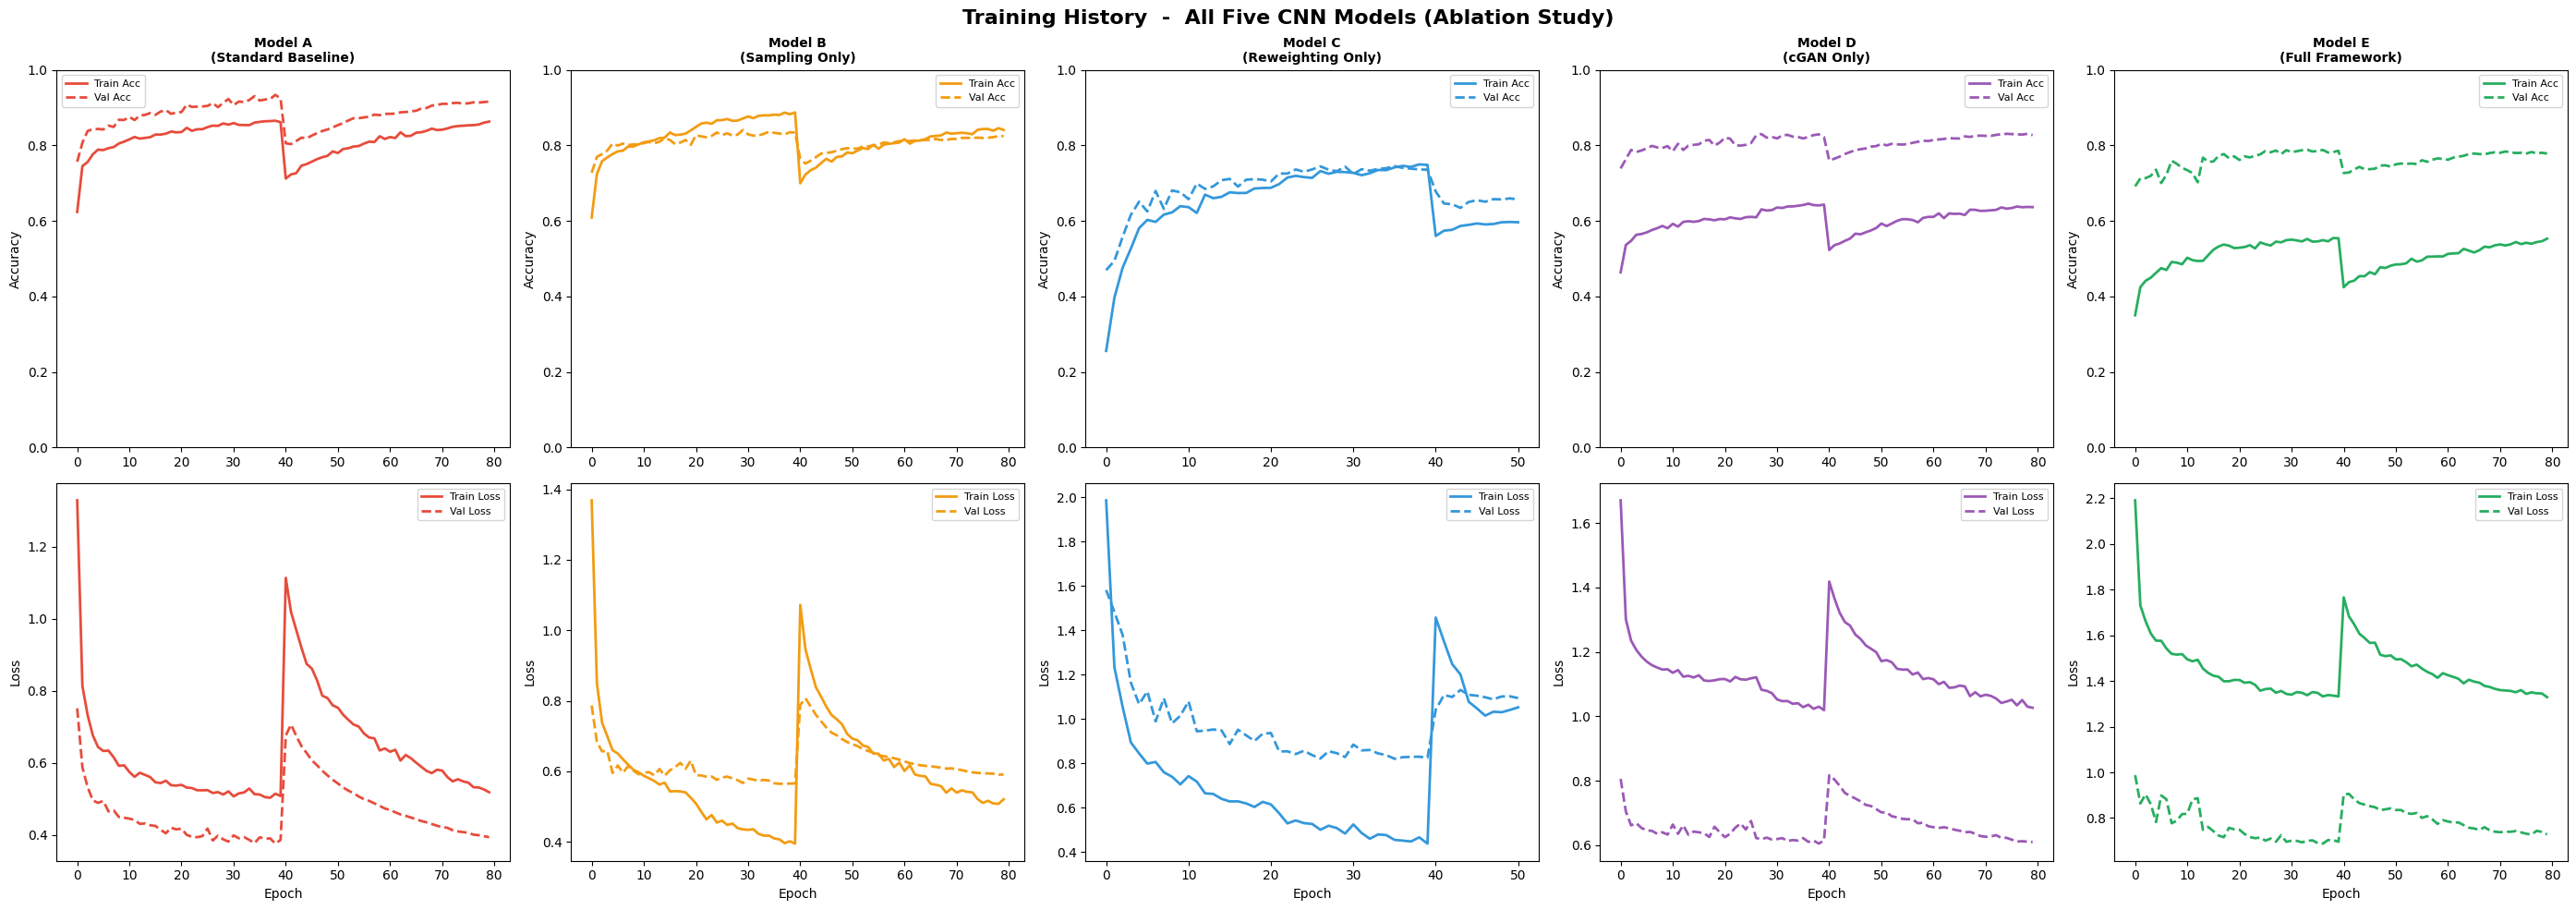

[OK] Training curves saved.


In [9]:
# CELL 8  -  Plot Training Curves (All Five Models)

# ── Shared style dictionary — used by every cell from here onward ────────────
# Defining this ONCE means renaming/adding models never breaks a plotting cell again.
MODEL_STYLE = {
    "Model_A_Standard_Baseline": {"color": "#e74c3c", "display": "Model A\n(Standard Baseline)", "ls": "-"},
    "Model_B_Sampling_Only":     {"color": "#f39c12", "display": "Model B\n(Sampling Only)",       "ls": "--"},
    "Model_C_Reweighting_Only":  {"color": "#3498db", "display": "Model C\n(Reweighting Only)",    "ls": "-."},
    "Model_D_cGAN_Only":         {"color": "#9b59b6", "display": "Model D\n(cGAN Only)",            "ls": ":"},
    "Model_E_Full_Framework":    {"color": "#27ae60", "display": "Model E\n(Full Framework)",       "ls": "-"},
}

fig, axes = plt.subplots(2, 5, figsize=(28, 10))
fig.suptitle("Training History  -  All Five CNN Models (Ablation Study)",
             fontweight="bold", fontsize=16)

for col, (name, h) in enumerate(histories.items()):
    style = MODEL_STYLE.get(name, {"color": "#7f8c8d", "display": name})
    color = style["color"]

    ax_acc  = axes[0, col]
    ax_loss = axes[1, col]

    ax_acc.plot(h["accuracy"],     label="Train Acc", color=color, linewidth=2)
    ax_acc.plot(h["val_accuracy"], label="Val Acc",   color=color, linewidth=2, linestyle="--")
    ax_acc.set_title(style["display"], fontweight="bold", fontsize=10)
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.set_ylim([0, 1])

    ax_loss.plot(h["loss"],     label="Train Loss", color=color, linewidth=2)
    ax_loss.plot(h["val_loss"], label="Val Loss",   color=color, linewidth=2, linestyle="--")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Training curves saved.")

# CELL 9  -  STEP 1.6: Prediction & Evaluation Helpers

In [10]:
def get_predictions(model, df_split):
    """
    Run inference on a split, return (true_labels, pred_labels, pred_probs).
    """
    paths  = df_split["image_path"].tolist()
    labels = df_split["label"].tolist()

    all_probs = []
    # Process in batches to avoid OOM
    for i in tqdm(range(0, len(paths), BATCH_SIZE), desc="Predicting"):
        batch_paths = paths[i:i+BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB").resize(IMG_SIZE)
                imgs.append(np.array(img, dtype=np.float32))   # NO /255.0
            except:
                imgs.append(np.zeros((*IMG_SIZE, 3), dtype=np.float32))
        batch_tensor = np.stack(imgs)
        probs = model.predict(batch_tensor, verbose=0)
        all_probs.extend(probs)

    all_probs  = np.array(all_probs)
    pred_labels = all_probs.argmax(axis=1)
    return np.array(labels), pred_labels, all_probs


def compute_standard_metrics(y_true, y_pred, y_probs):
    """
    Returns dict of standard diagnostic performance metrics.
    """
    acc  = accuracy_score(y_true, y_pred)
    # Multi-class AUC (OvR macro)
    try:
        auc = roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro")
    except:
        auc = float("nan")

    # Per-class sensitivity (recall) & specificity
    n_classes = y_probs.shape[1]
    sensitivities, specificities = [], []
    for c in range(n_classes):
        y_bin  = (y_true == c).astype(int)
        y_pred_bin = (y_pred == c).astype(int)
        tp = ((y_bin == 1) & (y_pred_bin == 1)).sum()
        fn = ((y_bin == 1) & (y_pred_bin == 0)).sum()
        tn = ((y_bin == 0) & (y_pred_bin == 0)).sum()
        fp = ((y_bin == 0) & (y_pred_bin == 1)).sum()
        sensitivities.append(tp / (tp + fn + 1e-8))
        specificities.append(tn / (tn + fp + 1e-8))

    return {
        "accuracy"   : round(acc, 4),
        "auc_macro"  : round(auc, 4),
        "sensitivity": round(np.mean(sensitivities), 4),  # macro avg
        "specificity": round(np.mean(specificities), 4),
        "per_class_sensitivity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(sensitivities)},
        "per_class_specificity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(specificities)},
    }


# CELL 10  -  STEP 1.6: Fairness Metrics

In [11]:
# CELL 10  -  Fairness Metrics (FIXED — index reset inside function)
def compute_fairness_metrics(df_split, y_true, y_pred, y_probs,
                              subgroup_col="age_group"):
    MEL_IDX = CLASS_NAMES.index("mel")

    # ── KEY FIX: always reset index so boolean mask aligns with y_true/y_pred ──
    df_split = df_split.reset_index(drop=True)

    groups = df_split[subgroup_col].unique()
    tpr_per_group = {}
    ppr_per_group = {}

    for grp in groups:
        mask = (df_split[subgroup_col] == grp).values

        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]

        mel_mask_g = (y_true_g == MEL_IDX)
        if mel_mask_g.sum() == 0:
            tpr_per_group[grp] = float("nan")
        else:
            tpr_per_group[grp] = round(
                ((y_pred_g == MEL_IDX) & mel_mask_g).sum() / mel_mask_g.sum(), 4
            )

        if len(y_pred_g) == 0:
            ppr_per_group[grp] = float("nan")
        else:
            ppr_per_group[grp] = round(
                (y_pred_g == MEL_IDX).sum() / len(y_pred_g), 4
            )

    valid_tpr = {k: v for k, v in tpr_per_group.items() if not np.isnan(v)}
    valid_ppr = {k: v for k, v in ppr_per_group.items() if not np.isnan(v)}

    eod = round(max(valid_tpr.values()) - min(valid_tpr.values()), 4) \
          if len(valid_tpr) >= 2 else float("nan")
    dp  = round(max(valid_ppr.values()) - min(valid_ppr.values()), 4) \
          if len(valid_ppr) >= 2 else float("nan")

    return {
        "subgroup_col": subgroup_col,
        "EOD"         : eod,
        "DP"          : dp,
        "TPR_per_group": tpr_per_group,
        "PPR_per_group": ppr_per_group,
    }

# CELL 11  -  Run Full Evaluation on All Three Models

In [12]:
# CELL 11  -  Run Full Evaluation on All Three Models

# ── compute_ece defined here so the cell is fully self-contained ──────────
def compute_ece(y_true, y_probs, n_bins=10):
    """Expected Calibration Error — measures how well confidence scores
    match actual accuracy. ECE = 0 is perfect calibration."""
    confidences = y_probs.max(axis=1)
    predictions = y_probs.argmax(axis=1)
    accuracies  = (predictions == y_true)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n   = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask   = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)

    return round(float(ece), 4)

# ── Main evaluation loop ──────────────────────────────────────────────────
models_dict = {
    "Model_A_Standard_Baseline": model_a,
    "Model_B_Sampling_Only"    : model_b,
    "Model_C_Reweighting_Only" : model_c,
    "Model_D_cGAN_Only"        : model_d,
    "Model_E_Full_Framework"   : model_e,
}
all_results = {}

for model_name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"  EVALUATING: {model_name}")
    print(f"{'='*60}")

    # Get predictions on TEST set
    y_true, y_pred, y_probs = get_predictions(model, df_test)

    # Standard metrics
    std_metrics = compute_standard_metrics(y_true, y_pred, y_probs)

    # ECE (calibration)
    ece = compute_ece(y_true, y_probs)

    # Fairness metrics for each demographic axis
    fairness_results = {}
    for col in ["age_group", "sex", "loc_zone"]:
        if col in df_test.columns:
            fairness_results[col] = compute_fairness_metrics(
                df_test.reset_index(drop=True), y_true, y_pred, y_probs,
                subgroup_col=col
            )

    all_results[model_name] = {
        "standard_metrics": std_metrics,
        "ece"             : ece,
        "fairness"        : fairness_results,
        "y_true"          : y_true,
        "y_pred"          : y_pred,
        "y_probs"         : y_probs,
    }

    print(f"\n  Standard Metrics:")
    print(f"    Accuracy    : {std_metrics['accuracy']:.4f}")
    print(f"    AUC (macro) : {std_metrics['auc_macro']:.4f}")
    print(f"    Sensitivity : {std_metrics['sensitivity']:.4f}")
    print(f"    Specificity : {std_metrics['specificity']:.4f}")
    print(f"    ECE         : {ece:.4f}")

    print(f"\n  Fairness Metrics:")
    for col, fm in fairness_results.items():
        eod_val = fm['EOD'] if not (isinstance(fm['EOD'], float) and np.isnan(fm['EOD'])) else float('nan')
        dp_val  = fm['DP']  if not (isinstance(fm['DP'],  float) and np.isnan(fm['DP']))  else float('nan')
        print(f"    [{col}] EOD={eod_val:.4f}  |  DP={dp_val:.4f}")

print(f"\n{'='*60}")
print("  All models evaluated successfully.")
print(f"{'='*60}")



  EVALUATING: Model_A_Standard_Baseline


Predicting: 100%|██████████| 47/47 [00:36<00:00,  1.30it/s]



  Standard Metrics:
    Accuracy    : 0.8589
    AUC (macro) : 0.9841
    Sensitivity : 0.7405
    Specificity : 0.9539
    ECE         : 0.0160

  Fairness Metrics:
    [age_group] EOD=0.2052  |  DP=0.0784
    [sex] EOD=0.0484  |  DP=0.0189
    [loc_zone] EOD=0.4688  |  DP=0.0950

  EVALUATING: Model_B_Sampling_Only


Predicting: 100%|██████████| 47/47 [00:30<00:00,  1.52it/s]



  Standard Metrics:
    Accuracy    : 0.7883
    AUC (macro) : 0.9481
    Sensitivity : 0.5964
    Specificity : 0.9363
    ECE         : 0.0631

  Fairness Metrics:
    [age_group] EOD=0.0670  |  DP=0.0634
    [sex] EOD=0.0303  |  DP=0.0132
    [loc_zone] EOD=0.3125  |  DP=0.0782

  EVALUATING: Model_C_Reweighting_Only


...


  Standard Metrics:
    Accuracy    : 0.6418
    AUC (macro) : 0.8820
    Sensitivity : 0.5685
    Specificity : 0.9253
    ECE         : 0.1112

  Fairness Metrics:
    [age_group] EOD=0.2292  |  DP=0.0504
    [sex] EOD=0.0205  |  DP=0.0020
    [loc_zone] EOD=0.3125  |  DP=0.0604

  EVALUATING: Model_D_cGAN_Only


Predicting: 100%|██████████| 47/47 [00:30<00:00,  1.53it/s]



  Standard Metrics:
    Accuracy    : 0.7951
    AUC (macro) : 0.9488
    Sensitivity : 0.5909
    Specificity : 0.9354
    ECE         : 0.0701

  Fairness Metrics:
    [age_group] EOD=0.0670  |  DP=0.0523
    [sex] EOD=0.0441  |  DP=0.0159
    [loc_zone] EOD=0.3750  |  DP=0.0726

  EVALUATING: Model_E_Full_Framework


Predicting: 100%|██████████| 47/47 [00:30<00:00,  1.52it/s]


  Standard Metrics:
    Accuracy    : 0.7463
    AUC (macro) : 0.9335
    Sensitivity : 0.6417
    Specificity : 0.9397
    ECE         : 0.0623

  Fairness Metrics:
    [age_group] EOD=0.0118  |  DP=0.0565
    [sex] EOD=0.0086  |  DP=0.0112
    [loc_zone] EOD=0.3333  |  DP=0.0326

  All models evaluated successfully.


# CELL 12  -  Summary Comparison Table

In [13]:
print("\n" + "=" * 70)
print("  COMPREHENSIVE MODEL COMPARISON TABLE")
print("=" * 70)

comparison_rows = []
for mname, res in all_results.items():
    sm = res["standard_metrics"]
    row = {
        "Model"       : mname.replace("_", " "),
        "Accuracy"    : sm["accuracy"],
        "AUC (macro)" : sm["auc_macro"],
        "Sensitivity" : sm["sensitivity"],
        "Specificity" : sm["specificity"],
        "ECE"         : res["ece"],
    }
    for col in ["age_group", "sex", "loc_zone"]:
        if col in res["fairness"]:
            fm = res["fairness"][col]
            row[f"EOD ({col})"] = fm["EOD"]
            row[f"DP ({col})"]  = fm["DP"]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
print(comparison_df)
comparison_df.to_csv(RESULTS_DIR / "model_comparison_table.csv")
print(f"\n[OK] Comparison table saved -> {RESULTS_DIR / 'model_comparison_table.csv'}")


  COMPREHENSIVE MODEL COMPARISON TABLE
                           Accuracy  AUC (macro)  Sensitivity  Specificity  \
Model                                                                        
Model A Standard Baseline    0.8589       0.9841       0.7405       0.9539   
Model B Sampling Only        0.7883       0.9481       0.5964       0.9363   
Model C Reweighting Only     0.6418       0.8820       0.5685       0.9253   
Model D cGAN Only            0.7951       0.9488       0.5909       0.9354   
Model E Full Framework       0.7463       0.9335       0.6417       0.9397   

                              ECE  EOD (age_group)  DP (age_group)  EOD (sex)  \
Model                                                                           
Model A Standard Baseline  0.0160           0.2052          0.0784     0.0484   
Model B Sampling Only      0.0631           0.0670          0.0634     0.0303   
Model C Reweighting Only   0.1112           0.2292          0.0504     0.0205   
Model D 

# CELL 13  -  Fairness Visualisation: EOD Across Models

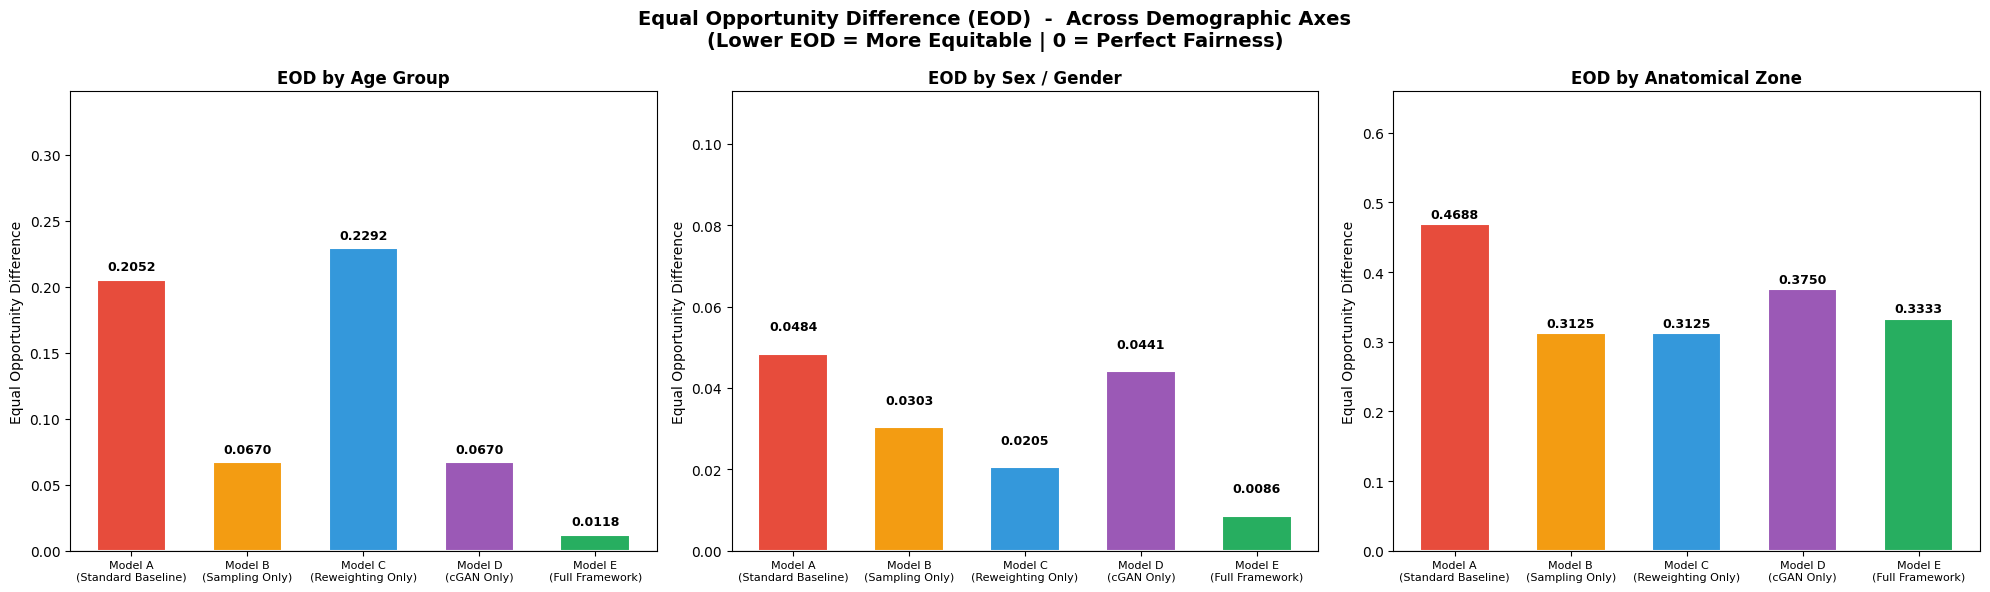

[OK] EOD comparison chart saved.


In [14]:
# CELL 13  -  Fairness Visualisation: EOD Across Models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Equal Opportunity Difference (EOD)  -  Across Demographic Axes\n"
             "(Lower EOD = More Equitable | 0 = Perfect Fairness)",
             fontweight="bold", fontsize=14)

demo_cols   = ["age_group", "sex", "loc_zone"]
demo_labels = ["Age Group", "Sex / Gender", "Anatomical Zone"]

model_display_names = [MODEL_STYLE[m]["display"] for m in models_dict.keys()]
model_colors_list   = [MODEL_STYLE[m]["color"]   for m in models_dict.keys()]

for ax_i, (col, label) in enumerate(zip(demo_cols, demo_labels)):
    eod_values = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_values.append(fm.get("EOD", 0))

    bars = axes[ax_i].bar(model_display_names, eod_values, color=model_colors_list,
                           edgecolor="white", linewidth=1.5, width=0.6)
    axes[ax_i].set_title(f"EOD by {label}", fontweight="bold")
    axes[ax_i].set_ylabel("Equal Opportunity Difference")
    axes[ax_i].set_ylim([0, max(eod_values) * 1.3 + 0.05])
    axes[ax_i].axhline(0, color="black", linewidth=0.8)
    axes[ax_i].tick_params(axis="x", labelsize=8)

    for bar, val in zip(bars, eod_values):
        axes[ax_i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f"{val:.4f}", ha="center", va="bottom",
                        fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fairness_eod_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] EOD comparison chart saved.")

# CELL 14  -  Subgroup Sensitivity Heatmap (Melanoma class)

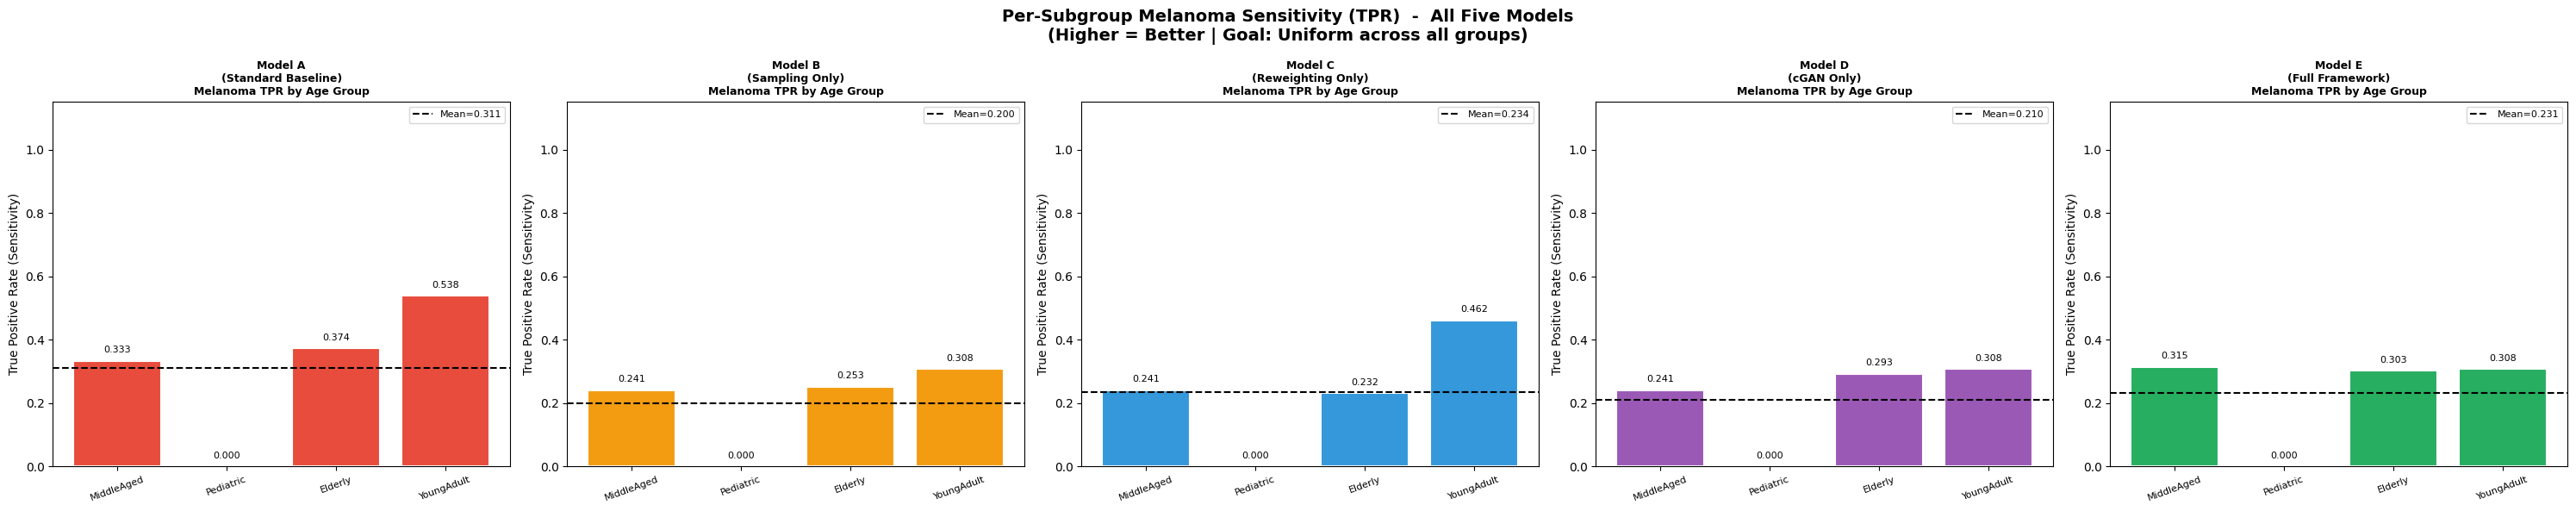

[OK] Subgroup sensitivity chart saved.


In [15]:
# CELL 14  -  Subgroup Sensitivity Heatmap (Melanoma class)
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
fig.suptitle("Per-Subgroup Melanoma Sensitivity (TPR)  -  All Five Models\n"
             "(Higher = Better | Goal: Uniform across all groups)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    style = MODEL_STYLE[mname]
    fm_age = all_results[mname]["fairness"].get("age_group", {})
    tpr_dict = fm_age.get("TPR_per_group", {})

    groups = list(tpr_dict.keys())
    tprs   = [tpr_dict[g] if not np.isnan(tpr_dict.get(g, float("nan"))) else 0
              for g in groups]

    bars = ax.bar(groups, tprs, color=style["color"], edgecolor="white", linewidth=1.5)
    ax.set_title(f"{style['display']}\nMelanoma TPR by Age Group", fontweight="bold", fontsize=9)
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_ylim([0, 1.15])
    ax.axhline(np.nanmean(tprs), color="black", linestyle="--",
               linewidth=1.5, label=f"Mean={np.nanmean(tprs):.3f}")
    ax.legend(fontsize=8)
    ax.set_xticklabels(groups, rotation=20, fontsize=8)

    for bar, val in zip(bars, tprs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "subgroup_melanoma_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Subgroup sensitivity chart saved.")


# CELL 15  -  Confusion Matrix for Each Model

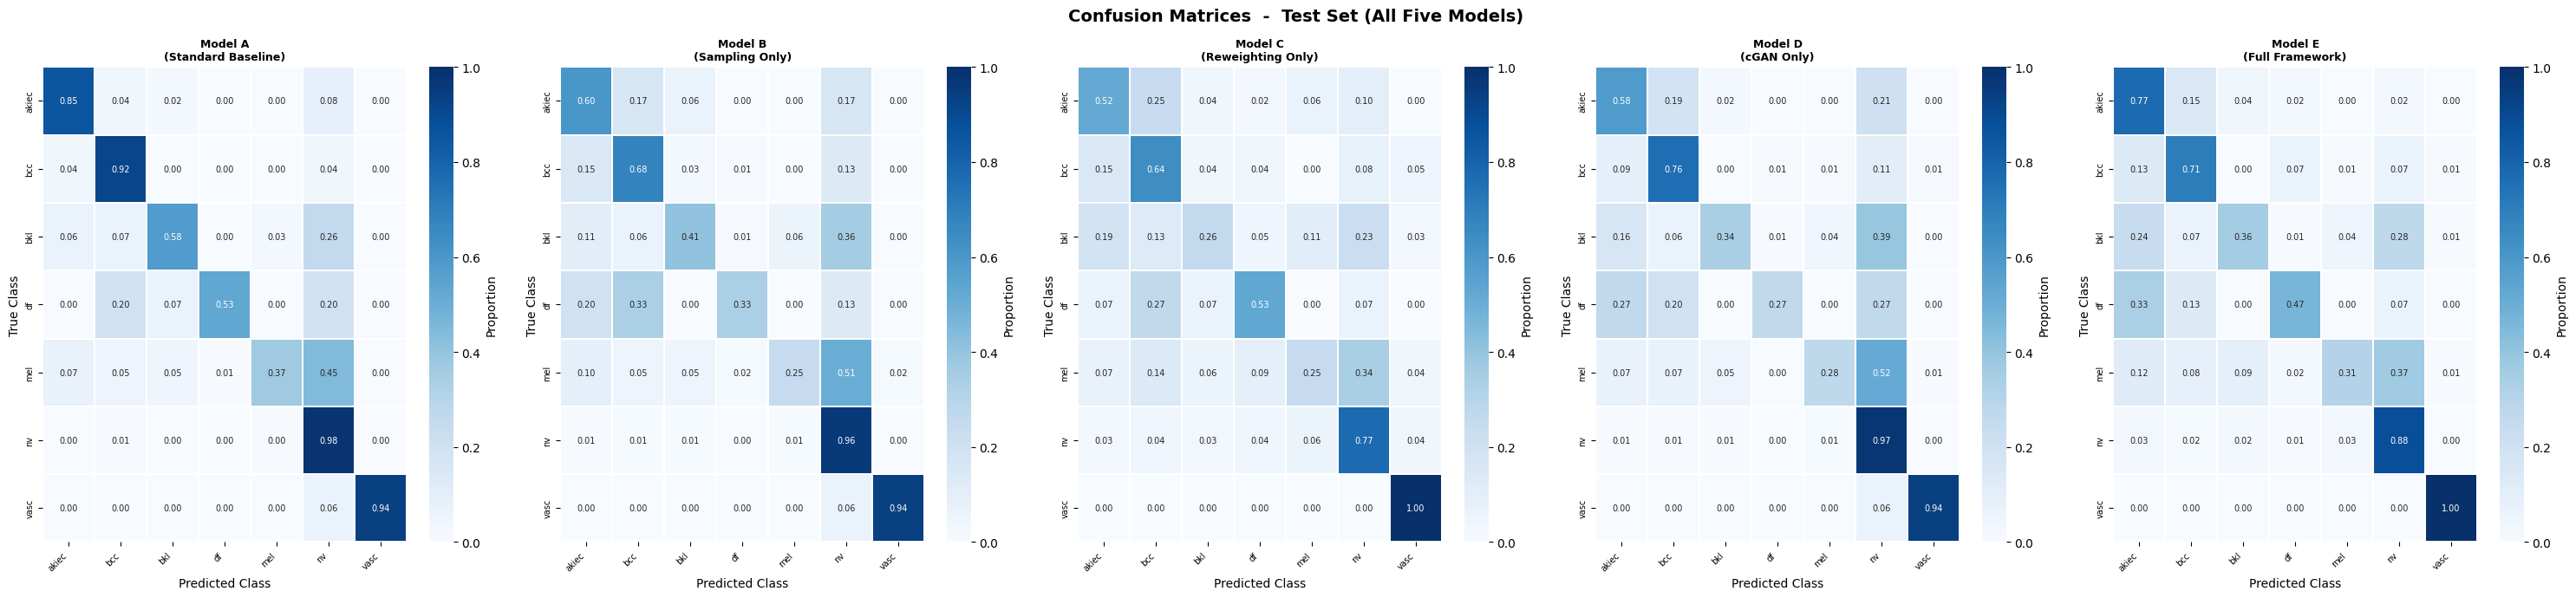

[OK] Confusion matrices saved.


In [16]:
# CELL 15  -  Confusion Matrix for Each Model
fig, axes = plt.subplots(1, 5, figsize=(30, 7))
fig.suptitle("Confusion Matrices  -  Test Set (All Five Models)", fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    y_true = all_results[mname]["y_true"]
    y_pred = all_results[mname]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, linewidths=0.3, linecolor="white",
                cbar_kws={"label": "Proportion"}, annot_kws={"size": 7})
    ax.set_title(MODEL_STYLE[mname]["display"], fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Confusion matrices saved.")


# CELL 16  -  ROC Curves for Melanoma Class

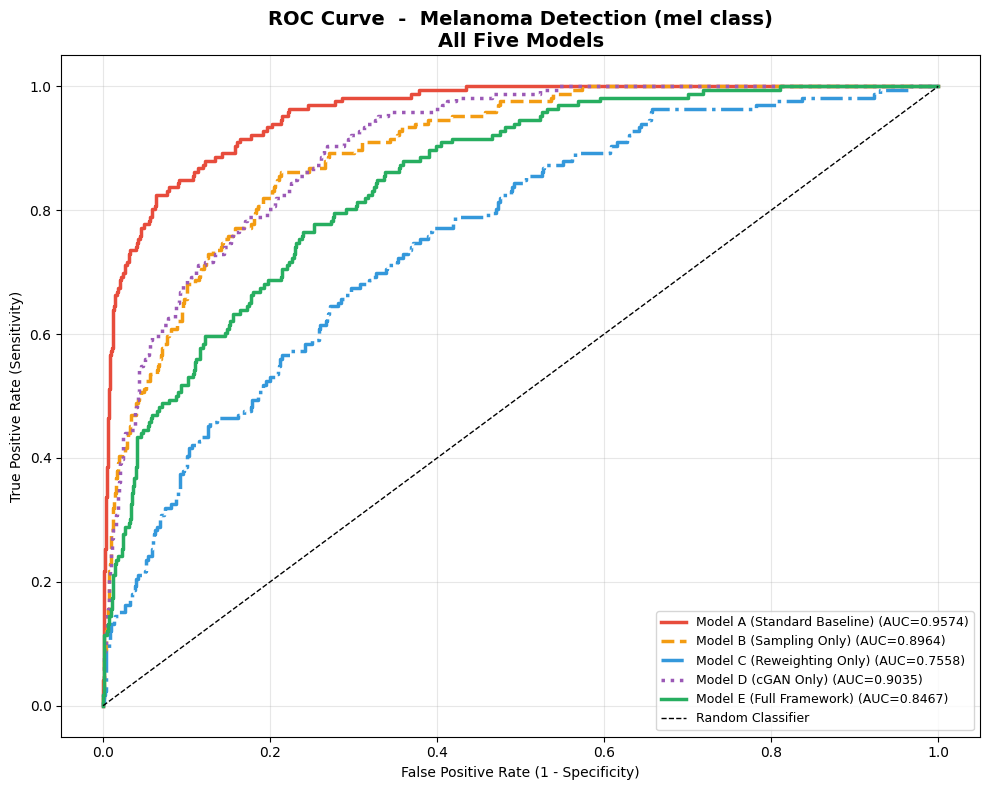

[OK] ROC curves saved.


In [17]:
# CELL 16  -  ROC Curves for Melanoma Class
fig, ax = plt.subplots(figsize=(10, 8))
MEL_IDX = CLASS_NAMES.index("mel")

for mname in models_dict.keys():
    style   = MODEL_STYLE[mname]
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]

    y_bin   = (y_true == MEL_IDX).astype(int)
    y_score = y_probs[:, MEL_IDX]

    fpr, tpr, _ = roc_curve(y_bin, y_score)
    auc_val = roc_auc_score(y_bin, y_score)

    ax.plot(fpr, tpr, color=style["color"], linestyle=style["ls"], linewidth=2.5,
            label=f"{style['display'].replace(chr(10), ' ')} (AUC={auc_val:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve  -  Melanoma Detection (mel class)\nAll Five Models",
             fontweight="bold", fontsize=14)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_melanoma.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] ROC curves saved.")

# CELL 17  -  Calibration Curves (ECE)

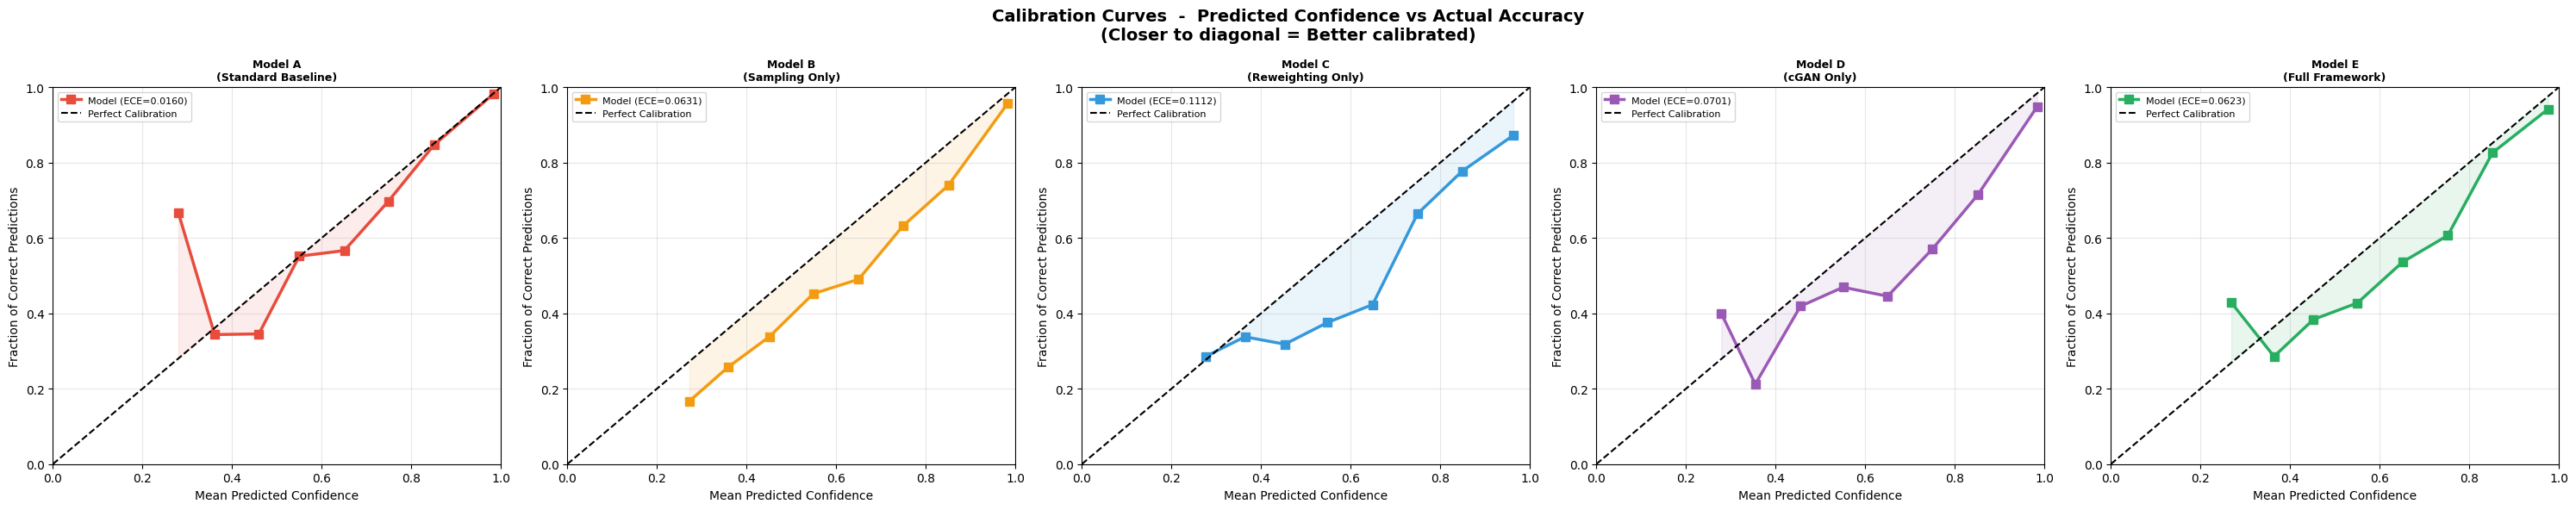

[OK] Calibration curves saved.


In [18]:
# CELL 17  -  Calibration Curves (ECE)
fig, axes = plt.subplots(1, 5, figsize=(30, 6))
fig.suptitle("Calibration Curves  -  Predicted Confidence vs Actual Accuracy\n"
             "(Closer to diagonal = Better calibrated)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    style   = MODEL_STYLE[mname]
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]
    ece     = all_results[mname]["ece"]

    confidences = y_probs.max(axis=1)
    is_correct  = (y_probs.argmax(axis=1) == y_true).astype(int)

    fraction_pos, mean_pred = calibration_curve(is_correct, confidences, n_bins=10)

    ax.plot(mean_pred, fraction_pos, "s-", color=style["color"], linewidth=2.5,
            markersize=7, label=f"Model (ECE={ece:.4f})")
    ax.plot([0,1],[0,1], "k--", linewidth=1.5, label="Perfect Calibration")
    ax.fill_between(mean_pred, fraction_pos, mean_pred, alpha=0.1, color=style["color"])

    ax.set_title(style["display"], fontweight="bold", fontsize=9)
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Fraction of Correct Predictions")
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Calibration curves saved.")

# CELL 18  -  Full Fairness Trade-off Dashboard

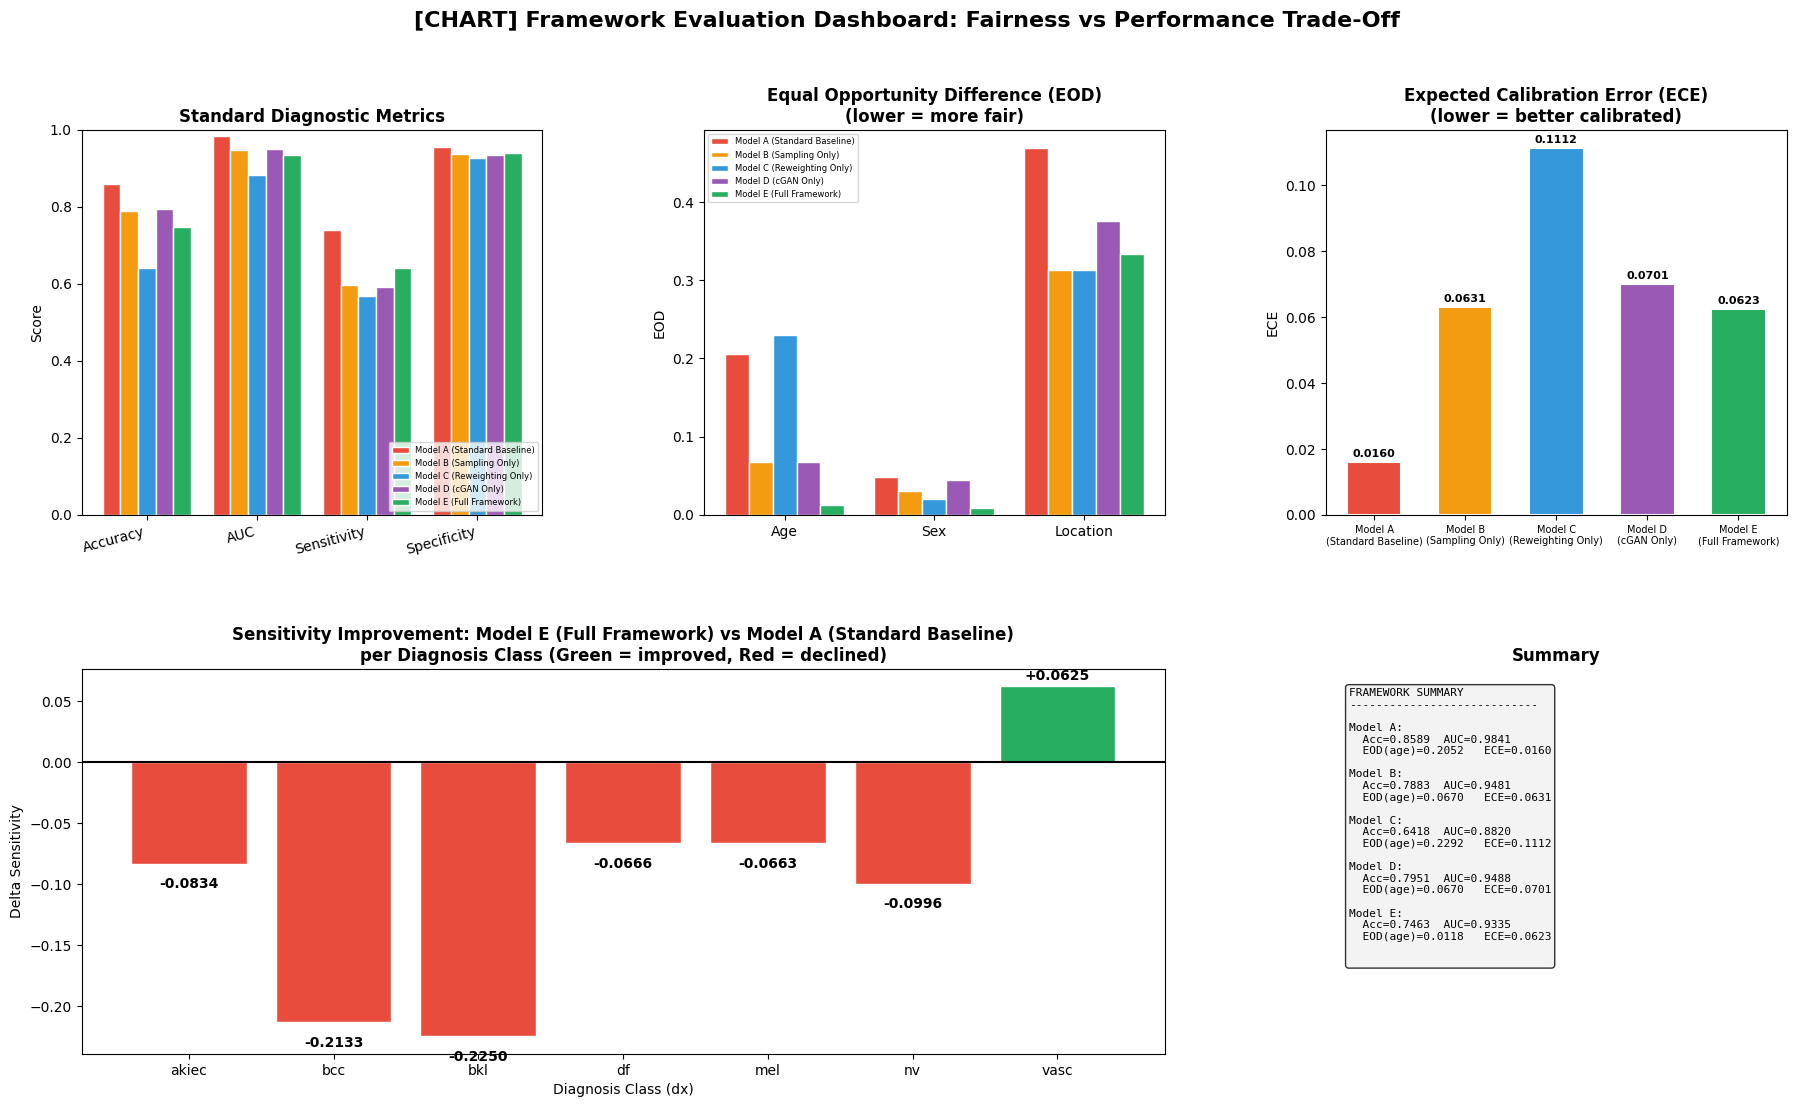

[OK] Full evaluation dashboard saved -> /kaggle/working/phase3_outputs/results/full_evaluation_dashboard.png


In [19]:
# CELL 18  -  Full Fairness Trade-off Dashboard
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("[CHART] Framework Evaluation Dashboard: Fairness vs Performance Trade-Off",
             fontweight="bold", fontsize=16)

model_display_names = [MODEL_STYLE[m]["display"] for m in models_dict.keys()]
model_colors_list   = [MODEL_STYLE[m]["color"]   for m in models_dict.keys()]
n_models = len(models_dict)

# Panel 1: Standard metrics comparison
ax1 = fig.add_subplot(gs[0, 0])
metrics_to_plot = ["accuracy", "auc_macro", "sensitivity", "specificity"]
metric_labels   = ["Accuracy", "AUC", "Sensitivity", "Specificity"]
x = np.arange(len(metrics_to_plot))
w = 0.8 / n_models   # ← auto-scales bar width for 5 models instead of fixed 0.25

for i, mname in enumerate(models_dict.keys()):
    style = MODEL_STYLE[mname]
    vals = [all_results[mname]["standard_metrics"][m] for m in metrics_to_plot]
    ax1.bar(x + i*w, vals, w, label=style["display"].replace("\n"," "),
            color=style["color"], edgecolor="white")

ax1.set_xticks(x + w * (n_models-1)/2)
ax1.set_xticklabels(metric_labels, rotation=15, ha="right")
ax1.set_ylim([0.0, 1.0])
ax1.set_title("Standard Diagnostic Metrics", fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=6, loc="lower right")

# Panel 2: EOD across demographic axes
ax2 = fig.add_subplot(gs[0, 1])
eod_data = {}
for col in ["age_group", "sex", "loc_zone"]:
    eod_data[col] = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_data[col].append(fm.get("EOD", 0))

x2 = np.arange(3)
w2 = 0.8 / n_models
for i, mname in enumerate(models_dict.keys()):
    style = MODEL_STYLE[mname]
    eods = [eod_data[col][i] for col in ["age_group","sex","loc_zone"]]
    ax2.bar(x2 + i*w2, eods, w2, label=style["display"].replace("\n"," "),
            color=style["color"], edgecolor="white")
ax2.set_xticks(x2 + w2 * (n_models-1)/2)
ax2.set_xticklabels(["Age","Sex","Location"])
ax2.set_title("Equal Opportunity Difference (EOD)\n(lower = more fair)", fontweight="bold")
ax2.set_ylabel("EOD")
ax2.legend(fontsize=6)

# Panel 3: ECE comparison
ax3 = fig.add_subplot(gs[0, 2])
ece_vals = [all_results[m]["ece"] for m in models_dict.keys()]
bars3 = ax3.bar(model_display_names, ece_vals, color=model_colors_list,
                edgecolor="white", linewidth=1.5, width=0.6)
ax3.set_title("Expected Calibration Error (ECE)\n(lower = better calibrated)", fontweight="bold")
ax3.set_ylabel("ECE")
ax3.tick_params(axis="x", labelsize=7)
for bar, val in zip(bars3, ece_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=8)

# Panel 4: Per-class sensitivity — Model A (Standard Baseline) vs Model E (Full Framework)
# ← THIS IS THE KEY COMPARISON: no-preprocessing vs full-framework
ax4 = fig.add_subplot(gs[1, :2])
per_class_a = all_results["Model_A_Standard_Baseline"]["standard_metrics"]["per_class_sensitivity"]
per_class_e = all_results["Model_E_Full_Framework"]["standard_metrics"]["per_class_sensitivity"]
delta = {cls: round(per_class_e[cls] - per_class_a[cls], 4) for cls in CLASS_NAMES}

bar_colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in delta.values()]
bars4 = ax4.bar(delta.keys(), delta.values(), color=bar_colors, edgecolor="white")
ax4.axhline(0, color="black", linewidth=1.5)
ax4.set_title("Sensitivity Improvement: Model E (Full Framework) vs Model A (Standard Baseline)\n"
              "per Diagnosis Class (Green = improved, Red = declined)", fontweight="bold")
ax4.set_xlabel("Diagnosis Class (dx)")
ax4.set_ylabel("Delta Sensitivity")
for bar, val in zip(bars4, delta.values()):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02
    ax4.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:+.4f}", ha="center", fontweight="bold", fontsize=10)

# Panel 5: Fairness Summary
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
summary_text = "FRAMEWORK SUMMARY\n" + "-"*28 + "\n\n"
for mname in models_dict.keys():
    sm  = all_results[mname]["standard_metrics"]
    eod_age = all_results[mname]["fairness"].get("age_group", {}).get("EOD","N/A")
    ece = all_results[mname]["ece"]
    short_name = MODEL_STYLE[mname]["display"].split("\n")[0]
    summary_text += f"{short_name}:\n"
    summary_text += f"  Acc={sm['accuracy']:.4f}  AUC={sm['auc_macro']:.4f}\n"
    summary_text += f"  EOD(age)={eod_age:.4f}   ECE={ece:.4f}\n\n"

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
         fontsize=8, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
ax5.set_title("Summary", fontweight="bold")

plt.savefig(RESULTS_DIR / "full_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Full evaluation dashboard saved -> {RESULTS_DIR / 'full_evaluation_dashboard.png'}")

#  CELL 19  -  Save All Results to JSON

In [20]:
# CELL 19  -  Save All Results to JSON
results_to_save = {}
for mname, res in all_results.items():
    results_to_save[mname] = {
        "standard_metrics": res["standard_metrics"],
        "ece"             : res["ece"],
        "fairness": {
            col: {
                "EOD"           : fm["EOD"],
                "DP"            : fm["DP"],
                "TPR_per_group" : fm["TPR_per_group"],
                "PPR_per_group" : fm["PPR_per_group"],
            }
            for col, fm in res["fairness"].items()
        }
    }

with open(RESULTS_DIR / "all_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

print(f"\n[OK] All evaluation results saved -> {RESULTS_DIR / 'all_results.json'}")

# ── Model paths for HMS integration ────────────────────────────────────────
# NOTE: The HMS only needs TWO models — the standard baseline (for
# the "before" comparison panel) and the full framework model (used for
# every live prediction). Models B, C and D exist only for the FYP
# ablation study and are NOT loaded by the Flask backend.
model_paths = {
    "baseline"     : str(MODELS_DIR / "Model_A_Standard_Baseline_final.h5"),
    "sampling_only": str(MODELS_DIR / "Model_B_Sampling_Only_final.h5"),
    "reweight_only": str(MODELS_DIR / "Model_C_Reweighting_Only_final.h5"),
    "cgan_only"    : str(MODELS_DIR / "Model_D_cGAN_Only_final.h5"),
    "enhanced_v2"  : str(MODELS_DIR / "Model_E_Full_Framework_final.h5"),  # ← used by HMS
}
with open(OUTPUT_DIR / "model_paths.json", "w") as f:
    json.dump(model_paths, f, indent=2)

print(f"[OK] Model paths saved -> {OUTPUT_DIR / 'model_paths.json'}")
print("\n[IMPORTANT] Update config.py in your HMS project:")
print('  MODEL_BASELINE    -> "Model_A_Standard_Baseline_final.h5"')
print('  MODEL_ENHANCED_V2 -> "Model_E_Full_Framework_final.h5"')



[OK] All evaluation results saved -> /kaggle/working/phase3_outputs/results/all_results.json
[OK] Model paths saved -> /kaggle/working/phase3_outputs/model_paths.json

[IMPORTANT] Update config.py in your HMS project:
  MODEL_BASELINE    -> "Model_A_Standard_Baseline_final.h5"
  MODEL_ENHANCED_V2 -> "Model_E_Full_Framework_final.h5"


# CELL 20  -  Phase 1 Completion Summary

In [21]:
# CELL 20  -  Phase 1 Completion Summary
print("\n" + "=" * 65)
print("  [DONE] PHASE 1 COMPLETE  -  ALL STEPS FINISHED")
print("=" * 65)
print("""
STEP 1.1  -  Dataset Preparation:
  [OK] HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  [OK] 70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  [OK] Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  [OK] WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  [OK] Synthetic images generated for rare demographic subgroups
  [OK] FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training (5-Model Ablation Study):
  [OK] Model A (Standard Baseline)  -  No preprocessing (Ali et al. 2022 replication)
  [OK] Model B (Sampling Only)      -  Intersectional stratified sampling only
  [OK] Model C (Reweighting Only)   -  Adaptive distribution-aware reweighting only
  [OK] Model D (cGAN Only)          -  Quality-controlled cGAN augmentation only
  [OK] Model E (Full Framework)     -  All three components combined (deployed in HMS)

STEP 1.6  -  Fairness Evaluation:
  [OK] Accuracy, AUC-ROC, Sensitivity, Specificity (all 5 models)
  [OK] EOD & Demographic Parity (age, sex, localization)
  [OK] Expected Calibration Error (ECE)
  [OK] Dashboard charts & comparison table saved

OUTPUTS SAVED TO:   ./phase1_outputs/
  models/     -> .h5 model files for all 5 models
  results/    -> charts, comparison table, all_results.json
  splits/     -> train/val/test CSVs
  cgan/       -> generator checkpoint, training curves
  synthetic_images/ -> generated images per rare subgroup

NEXT STEP -> Begin PHASE 2: HMS Backend (Flask + Database)
""")



  [DONE] PHASE 1 COMPLETE  -  ALL STEPS FINISHED

STEP 1.1  -  Dataset Preparation:
  [OK] HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  [OK] 70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  [OK] Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  [OK] WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  [OK] Synthetic images generated for rare demographic subgroups
  [OK] FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training (5-Model Ablation Study):
  [OK] Model A (Standard Baseline)  -  No preprocessing (Ali et al. 2022 replication)
  [OK] Model B (Sampling Only)      -  Intersectional stratified sampling only
  [OK] Model C (Reweighting Only)   -  Adaptive distribution-aware reweighting only
  [OK] Model D (cGAN Only)          -  Quality-controlled cGAN augmentation 

# End of Phase 2

In [22]:
# FINAL CELL — Package trained models for download
import shutil, os

print("Model files saved:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.suffix == ".h5":
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name}  ({size_mb:.1f} MB)")

shutil.make_archive("/kaggle/working/melanoscan_trained_models", "zip", MODELS_DIR)
zip_size = os.path.getsize("/kaggle/working/melanoscan_trained_models.zip") / (1024*1024)
print(f"\n[OK] melanoscan_trained_models.zip ({zip_size:.1f} MB)")
print("Download from the Output panel → melanoscan_trained_models.zip")

Model files saved:
  Model_A_Standard_Baseline_final.h5  (31.4 MB)
  Model_A_Standard_Baseline_phase1_best.h5  (20.0 MB)
  Model_A_Standard_Baseline_phase2_best.h5  (31.4 MB)
  Model_B_Sampling_Only_final.h5  (31.4 MB)
  Model_B_Sampling_Only_phase1_best.h5  (20.0 MB)
  Model_B_Sampling_Only_phase2_best.h5  (31.4 MB)
  Model_C_Reweighting_Only_final.h5  (31.4 MB)
  Model_C_Reweighting_Only_phase1_best.h5  (20.0 MB)
  Model_C_Reweighting_Only_phase2_best.h5  (31.4 MB)
  Model_D_cGAN_Only_final.h5  (31.4 MB)
  Model_D_cGAN_Only_phase1_best.h5  (20.0 MB)
  Model_D_cGAN_Only_phase2_best.h5  (31.4 MB)
  Model_E_Full_Framework_final.h5  (31.4 MB)
  Model_E_Full_Framework_phase1_best.h5  (20.0 MB)
  Model_E_Full_Framework_phase2_best.h5  (31.4 MB)

[OK] melanoscan_trained_models.zip (372.7 MB)
Download from the Output panel → melanoscan_trained_models.zip
